#### Install

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.7 MB/s eta 0:00:00


#### Seed, Plot, Multi-seed

In [2]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.utils import to_undirected
from torch_geometric.nn import GATv2Conv

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, classification_report
)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def plot_learning_curves(history: dict, model_name: str = "Model") -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.plot(epochs, history['train_loss'], label='Train Loss')
    ax.plot(epochs, history['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} – Loss')
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    ax.plot(epochs, history['train_f1'], label='Train F1 (illicit)')
    ax.plot(epochs, history['val_f1'], label='Val F1 (illicit)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1-score')
    ax.set_title(f'{model_name} – F1 (illicit)')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

def run_multiseed(run_single_seed_fn, exp_name="Experiment", seeds=[42, 0, 123]):
    results = []
    for seed in seeds:
        print(f"\n{exp_name} - Seed: {seed}")
        metrics = run_single_seed_fn(seed)
        metrics['seed'] = seed
        results.append(metrics)
        
    print(f"\n {exp_name} multi-seed results")
    metric_keys = [k for k in results[0].keys() if k != 'seed']
    
    for key in metric_keys:
        values = [res[key] for res in results]
        mean_val = np.mean(values)
        std_val = np.std(values)
        
        display_key = {'f1_ill': 'F1(illicit)', 'precision': 'Precision', 'recall': 'Recall', 'auc_pr': 'AUC-PR'}.get(key, key.capitalize())
        print(f"{display_key:<11}: {mean_val:.4f} ± {std_val:.4f}")
        
    return results


#### Integrate data processing logic and GAT model architecture

In [3]:
def load_and_preprocess_data(data_path: str, device: torch.device | None = None, undirected: bool = True) -> tuple:
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    data = torch.load(data_path, weights_only=False)
    
    if undirected:
        data.edge_index = to_undirected(data.edge_index)

    train_features = data.x[data.train_mask]
    train_mean = train_features.mean(dim=0)
    train_std = train_features.std(dim=0)
    data.x = (data.x - train_mean) / (train_std + 1e-8)
    print(data)
    
    data = data.to(device)
    return data, device

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

#### Consolidate model evaluation and early stopping loops

In [4]:
def compute_class_weights(data, device: torch.device) -> torch.Tensor:
    n_licit = (data.y[data.train_mask] == 0).sum().item()
    n_illicit = (data.y[data.train_mask] == 1).sum().item()
    weight = torch.tensor([1.0, math.sqrt(n_licit / n_illicit)], dtype=torch.float).to(device)
    return weight

def evaluate(model, data, criterion, mask) -> dict:
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1)
        probs = F.softmax(out[mask], dim=1)[:, 1]
        y_true, y_pred, y_prob = data.y[mask].cpu().numpy(), pred.cpu().numpy(), probs.cpu().numpy()
        loss = criterion(out[mask], data.y[mask]).item()

    return {
        'loss': loss, 'accuracy': accuracy_score(y_true, y_pred),
        'precision_ill': precision_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'recall_ill': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_ill': f1_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0), 
        'auc_pr': average_precision_score(y_true, y_prob),
    }

def train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=None):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    if clip_grad_norm is not None:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
    optimizer.step()
    return loss.item()

def train_with_early_stopping(model, data, optimizer, criterion, save_path: str, num_epochs: int = 200, patience: int = 20, monitor_metric: str = 'f1_ill', clip_grad_norm=None, scheduler=None) -> dict:
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_score, epochs_no_improve, best_epoch = 0.0, 0, 0

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=clip_grad_norm)
        train_metrics = evaluate(model, data, criterion, data.train_mask)
        val_metrics = evaluate(model, data, criterion, data.val_mask)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_f1'].append(train_metrics['f1_ill'])
        history['val_f1'].append(val_metrics['f1_ill'])

        if scheduler is not None: scheduler.step()

        if val_metrics[monitor_metric] > best_val_score:
            best_val_score, best_epoch, epochs_no_improve = val_metrics[monitor_metric], epoch, 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, Val Loss={val_metrics['loss']:.4f}, Train F1={train_metrics['f1_ill']:.4f}, Val F1={val_metrics['f1_ill']:.4f}, Gap={train_metrics['f1_ill'] - val_metrics['f1_ill']:.4f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (Best epoch: {best_epoch})")
            break
    return history

def print_test_evaluation(model, data, criterion, label: str = "Test") -> None:
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    print(f"{label}\n  Loss          : {test_metrics['loss']:.4f}\n  Accuracy      : {test_metrics['accuracy']:.4f}\n  Precision(ill): {test_metrics['precision_ill']:.4f}\n  Recall(ill)   : {test_metrics['recall_ill']:.4f}\n  F1(illicit)   : {test_metrics['f1_ill']:.4f}\n  F1(macro)     : {test_metrics['f1_macro']:.4f}\n  AUC-PR        : {test_metrics['auc_pr']:.4f}")

    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1)
        y_true, y_pred = data.y[data.test_mask].cpu().numpy(), pred.cpu().numpy()

    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)'], digits=4, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


#### Implement main execution block pointing to Kaggle dataset paths

Device: cuda
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Start training GAT on Kaggle

GAT - Seed: 42
GAT Train - Seed: 42
Epoch 001: Train Loss=2.1208, Val Loss=1.2583, Train F1=0.0985, Val F1=0.0055, Gap=0.0930
Epoch 002: Train Loss=2.0536, Val Loss=0.7308, Train F1=0.1217, Val F1=0.0152, Gap=0.1065
Epoch 003: Train Loss=1.3445, Val Loss=0.7060, Train F1=0.1601, Val F1=0.0254, Gap=0.1347
Epoch 004: Train Loss=1.6247, Val Loss=0.6850, Train F1=0.2025, Val F1=0.0498, Gap=0.1527
Epoch 005: Train Loss=2.0616, Val Loss=0.6683, Train F1=0.2564, Val F1=0.1194, Gap=0.1370
Epoch 006: Train Loss=1.8141, Val Loss=0.6558, Train F1=0.2969, Val F1=0.1839, Gap=0.1129
Epoch 007: Train Loss=1.1037, Val Loss=0.6470, Train F1=0.3356, Val F1=0.2140, Gap=0.1217
Epoch 008: Train Loss=1.8646, Val Loss=0.6434, Train F1=0.3624, Val F1=0.2260, Gap=0.1365
Epoch 009: Train Loss=0.9690, Val Loss=0.6437, Train F1=0.3776, Val F1=0.2221, Gap=

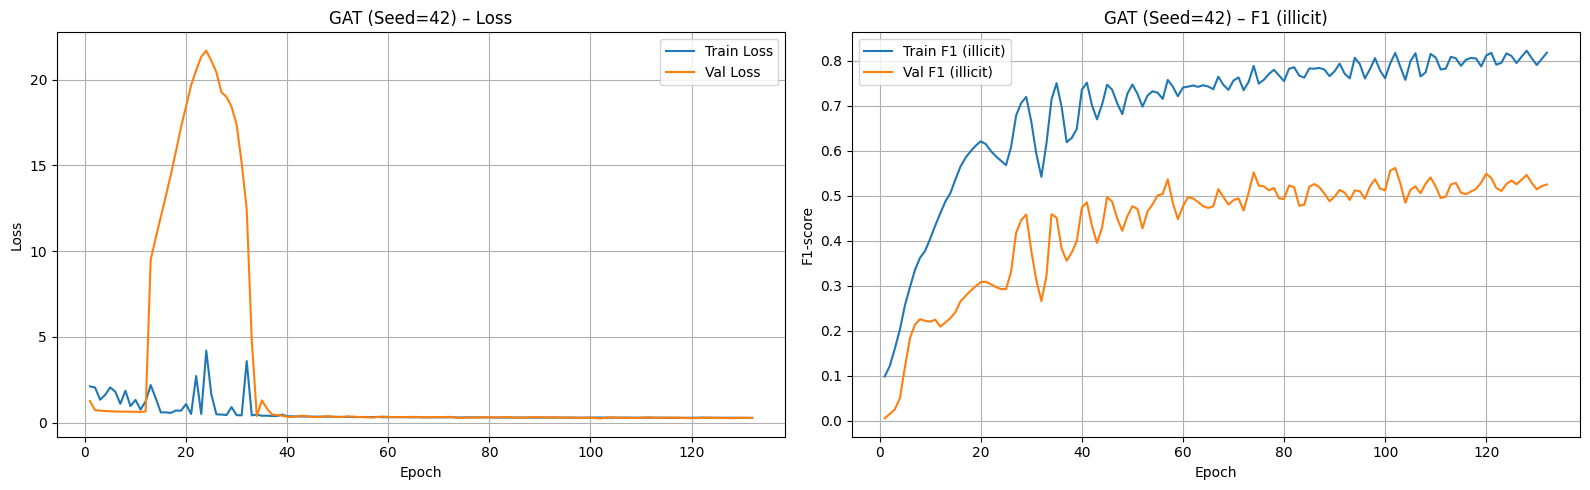

GAT Test - Seed: 42
  Loss          : 0.3246
  Accuracy      : 0.9213
  Precision(ill): 0.5698
  Recall(ill)   : 0.7518
  F1(illicit)   : 0.6483
  F1(macro)     : 0.8020
  AUC-PR        : 0.7518

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9726    0.9394    0.9557      5132
 Illicit (1)     0.5698    0.7518    0.6483       548

    accuracy                         0.9213      5680
   macro avg     0.7712    0.8456    0.8020      5680
weighted avg     0.9337    0.9213    0.9260      5680

Confusion Matrix:
 [[4821  311]
 [ 136  412]]

GAT - Seed: 0
GAT Train - Seed: 0
Epoch 001: Train Loss=1.0665, Val Loss=9.4885, Train F1=0.2911, Val F1=0.1672, Gap=0.1239
Epoch 002: Train Loss=0.9886, Val Loss=9.3832, Train F1=0.3174, Val F1=0.1765, Gap=0.1409
Epoch 003: Train Loss=0.9679, Val Loss=9.2766, Train F1=0.3435, Val F1=0.1752, Gap=0.1683
Epoch 004: Train Loss=0.9719, Val Loss=9.1196, Train F1=0.3642, Val F1=0.1761, Gap=0.1881
Epoch 005: T

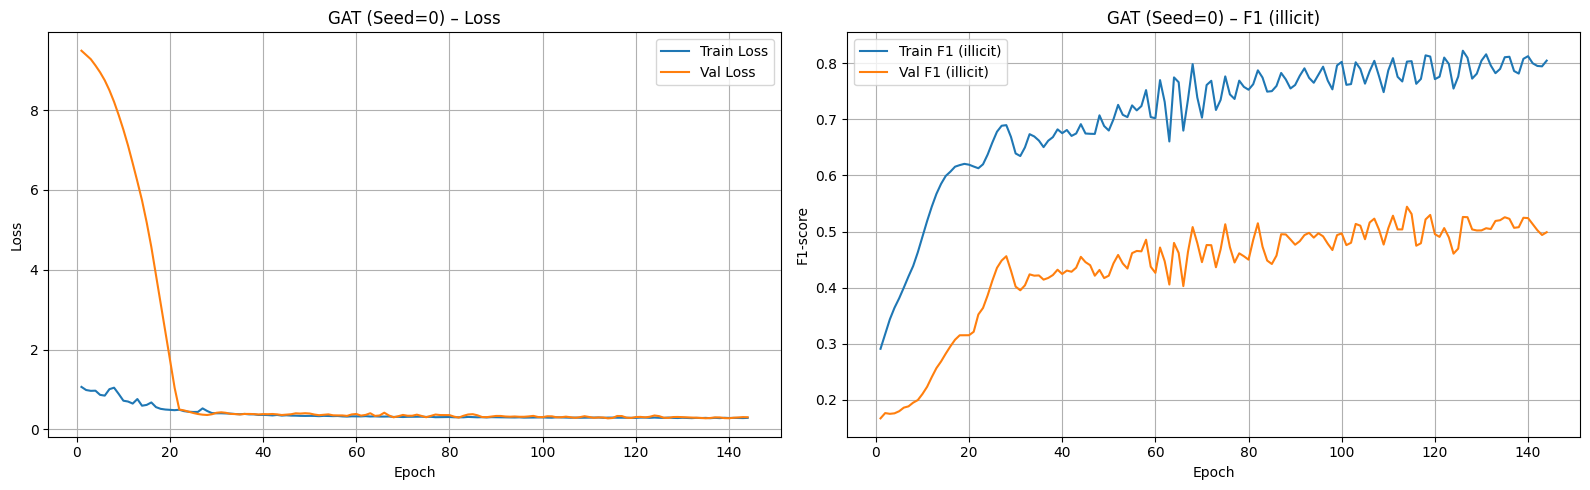

GAT Test - Seed: 0
  Loss          : 0.2917
  Accuracy      : 0.9083
  Precision(ill): 0.5163
  Recall(ill)   : 0.7792
  F1(illicit)   : 0.6211
  F1(macro)     : 0.7845
  AUC-PR        : 0.7325

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9751    0.9221    0.9478      5132
 Illicit (1)     0.5163    0.7792    0.6211       548

    accuracy                         0.9083      5680
   macro avg     0.7457    0.8506    0.7845      5680
weighted avg     0.9308    0.9083    0.9163      5680

Confusion Matrix:
 [[4732  400]
 [ 121  427]]

GAT - Seed: 123
GAT Train - Seed: 123
Epoch 001: Train Loss=1.5829, Val Loss=8.2692, Train F1=0.1577, Val F1=0.0866, Gap=0.0711
Epoch 002: Train Loss=1.2535, Val Loss=6.4557, Train F1=0.2043, Val F1=0.1059, Gap=0.0984
Epoch 003: Train Loss=1.1451, Val Loss=4.9946, Train F1=0.2430, Val F1=0.1221, Gap=0.1209
Epoch 004: Train Loss=1.5171, Val Loss=3.6759, Train F1=0.2871, Val F1=0.1559, Gap=0.1312
Epoch 005

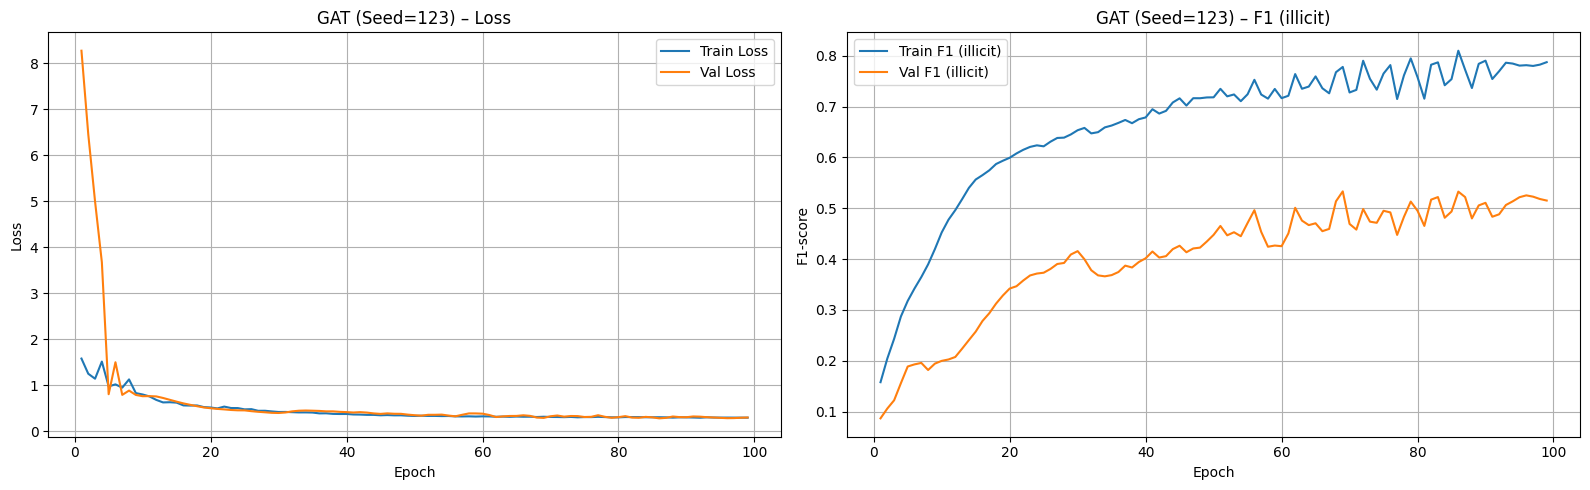

GAT Test - Seed: 123
  Loss          : 0.3406
  Accuracy      : 0.9014
  Precision(ill): 0.4926
  Recall(ill)   : 0.7281
  F1(illicit)   : 0.5876
  F1(macro)     : 0.7658
  AUC-PR        : 0.7157

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9694    0.9199    0.9440      5132
 Illicit (1)     0.4926    0.7281    0.5876       548

    accuracy                         0.9014      5680
   macro avg     0.7310    0.8240    0.7658      5680
weighted avg     0.9234    0.9014    0.9096      5680

Confusion Matrix:
 [[4721  411]
 [ 149  399]]

 GAT multi-seed results
Loss       : 0.3189 ± 0.0204
Accuracy   : 0.9103 ± 0.0083
Precision_ill: 0.5263 ± 0.0323
Recall_ill : 0.7530 ± 0.0209
F1(illicit): 0.6190 ± 0.0248
F1_macro   : 0.7841 ± 0.0148
AUC-PR     : 0.7333 ± 0.0148


In [8]:
data_path = '/kaggle/input/datasets/meowll/elliptic-graph-data/elliptic_pyg_data.pt'

data, device = load_and_preprocess_data(data_path, undirected=True)

def run_single_gcn_seed(seed):
    torch.cuda.empty_cache()
    set_seed(seed)
    print(f"GAT Train - Seed: {seed}")
    
    model = GAT(
        in_channels=data.x.shape[1], 
        hidden_channels=128,
        out_channels=2, 
        heads=4,      
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.005, steps_per_epoch=1, epochs=300, pct_start=0.2,
    )
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    save_path = f'/kaggle/working/gat_best_seed_{seed}.pt'
    
    history = train_with_early_stopping(
        model, data, optimizer, criterion, scheduler=scheduler,
        save_path=save_path, num_epochs=300, patience=30,
        monitor_metric='f1_ill', clip_grad_norm=1.0
    )
    
    plot_learning_curves(history, model_name=f"GAT (Seed={seed})")
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    print_test_evaluation(model, data, criterion, label=f"GAT Test - Seed: {seed}")
    
    return evaluate(model, data, criterion, data.test_mask)

print("Start training GAT on Kaggle")
results = run_multiseed(run_single_gcn_seed, "GAT", seeds=[42, 0, 123])